# Neuron optimization

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrand
import snnax
import snnax.snn as snn

from eleanor.models import Bruno, Heracles, Scaler

In [2]:
key = jrand.key(0)
kmodel, kstate, ksim = jrand.split(key, 3)

model = snn.Sequential(
    Heracles(V_thr=2.5, dt=1e-3, paramsScale=1e12, key=kmodel),
    # Scaler(1000, 1000),
    # FeLIF(),
)
model

Sequential(
  graph_structure=GraphStructure(
    num_layers=1, input_layer_ids=((0,),), input_connectivity=((),)
  ),
  layers=[
    Heracles(
      init_fn=<function <lambda>>,
      shape=None,
      A=25.0,
      t_fe=9800.0,
      eps_fe=70,
      eps_depl=3.6,
      q_fix_depl=0.0945,
      n_depl=1.4e+16,
      e_off=2e-05,
      temp=294,
      w_b=1.05,
      d_e=7499.999999999999,
      P_s=0.27,
      I_0=0.0001,
      V_t=0.32,
      C_par=0.015,
      C_fe=1.5811049864186066,
      C_tot_init=weak_f32[],
      I_dsc=10.0,
      V_thr=2.5,
      dt=0.001,
      _eps0=8.854187923944199,
      _q=1.6021766299999998e-07,
      _k=1.3806490000000002e-11,
      _h=6.6260701499999995e-22,
      spike_fn=<function superspike_surrogate.<locals>.heaviside_with_superspike_surrogate>,
      A_var=D2DVar(name='A', variability=0.0, key=key<fry>[]),
      n_depl_var=D2DVar(name='n_depl', variability=0.0, key=key<fry>[]),
      P_s_var=D2DVar(name='P_s', variability=0.0, key=key<fry>[]),


In [3]:
state = model.init_state((1,), kstate)
state

[[Array([0.], dtype=float32),
  Array([-0.27], dtype=float32),
  Array([0.], dtype=float32)]]

In [4]:
# input_ = 100 * jnp.concatenate([jnp.ones((300, 1)), jnp.zeros((200, 1))])
# states, outs = model(state, input_, key=jax.random.key(0))
input_ = 100 * jnp.concatenate([jnp.ones((50, 1)), jnp.zeros((50, 1))])
states, outs = model(state, input_, key=ksim)

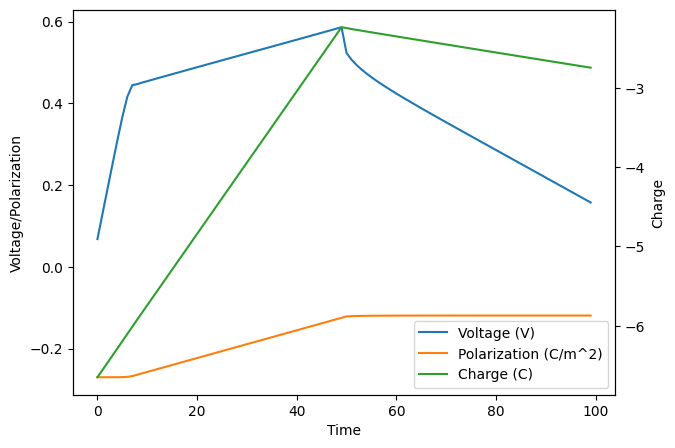

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# sns.set_theme()

# plt.plot(outs[0][1], label="Voltage (V)")
# plt.plot(outs[0][2], label="Polarization (C/m^2)")
# plt.plot(
#     outs[0][1] * outs[0][3] + outs[0][2] * model.layers[0].A,
#     label="Charge (pC)",
# )
# plt.legend()
# plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
default_prop_cycler = plt.rcParams["axes.prop_cycle"]
lns1 = ax.plot(outs[0][1], label="Voltage (V)")
lns2 = ax.plot(outs[0][2], label="Polarization (C/m^2)")
ax2 = ax.twinx()
lns3 = ax2.plot(
    outs[0][1] * outs[0][3] + outs[0][2] * model.layers[0].A,
    c=ax._get_lines.get_next_color(),
    label="Charge (C)",
)
lns = lns1 + lns2 + lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=4)
ax.set_xlabel("Time")
ax.set_ylabel("Voltage/Polarization")
ax2.set_ylabel("Charge")
plt.show()

In [6]:
import matplotlib.pyplot as plt
import optax
from tqdm import trange
from eleanor.models import FeLIF, Heracles, Scaler
import equinox as eqx
import jax.numpy as jnp
import jax
import snnax
import snnax.snn as snn

In [23]:
key = jax.random.key(0)

# linearLayer = eqx.nn.Linear(1, 1, use_bias=False, key=key)
# new_weight = jnp.asarray([[1.0]])
# linearLayer = eqx.tree_at(lambda x: x.weight, linearLayer, new_weight)
linearLayer = eqx.nn.Linear(1, 1, use_bias=False, key=key)
new_weight = jnp.asarray([[0.3]])
linearLayer = eqx.tree_at(lambda x: x.weight, linearLayer, new_weight)

model = snn.Sequential(
    linearLayer,
    Scaler(100, 100),
    # Bruno(
    #     dt=1e-3,
    #     A=25e-12,
    #     I_dsc=0,  # 3.2532312693054174e-11,
    #     V_thr=1.698682296181096,
    #     P_s=0.22,  # 0.13321217250476625,
    #     spike_fn=snnax.functional.surrogate.superspike_surrogate(beta=10.0),
    #     paramsScale=1e12,
    # ),
    # Scaler(100, 100),
    Heracles(
        dt=1e-3,
        # I_dsc=3.2532312693054174e-11,
        V_thr=0.3,
        # P_s=0.13321217250476625,
        spike_fn=snnax.functional.surrogate.superspike_surrogate(beta=10.0),
        paramsScale=1e12,
        key=kmodel,
    ),
)
init_state = model.init_state((1,), kstate)
_, outs = model(init_state, jnp.zeros((10, 1)), ksim)

In [24]:
@eqx.filter_jit
def predict(model, input_):
    init_state = model.init_state((1,), jax.random.key(0))
    _, outs = model(init_state, input_, jax.random.key(0))

    # return outs[0][0], outs[0][1], outs[0][2], outs[0][3]
    return outs[0][0], outs[0][1], outs[0][2]


@eqx.filter_jit
def loss(model, input_, target):
    # preds, _, _, _ = predict(model, input_)
    preds, _, _ = predict(model, input_)
    preds = jnp.sum(preds, axis=0)  # Sum over time
    return jnp.mean((preds - target) ** 2)

In [25]:
opt = optax.adam(learning_rate=5e-3)
opt_state = opt.init(eqx.filter(model, eqx.is_inexact_array))

In [26]:
# Input every 5ms
input_ = jnp.array([[0], [0], [0], [0], [0], [0], [0], [0], [0], [1.0]] * 10)
target = jnp.array([2.0])

In [27]:
print("Optimizing")
loss_rec = []
param_rec = []
state = [model, opt_state]
nb_epochs = 300
for _ in trange(nb_epochs):
    grad_params, opt_state = state

    loss_val, grads = eqx.filter_value_and_grad(loss)(grad_params, input_, target)
    updates, opt_state = opt.update(grads, opt_state, grad_params)
    loss_rec.append(loss_val)

    new_param = eqx.apply_updates(grad_params, updates)
    state = [new_param, opt_state]
    param_rec.append(new_param.layers[0].weight[0, 0])
loss_rec = jnp.stack(loss_rec)
param_rec = jnp.stack(param_rec)

Optimizing


100%|██████████| 300/300 [00:05<00:00, 54.11it/s] 


In [28]:
print("Predict")
# preds_before, V_before, P_before, C_before = predict(model, input_)
# preds, V, P, C_after = predict(state[0], input_)
preds_before, V_before, P_before = predict(model, input_)
preds, V, P = predict(state[0], input_)
print("Finish")

Predict
Finish


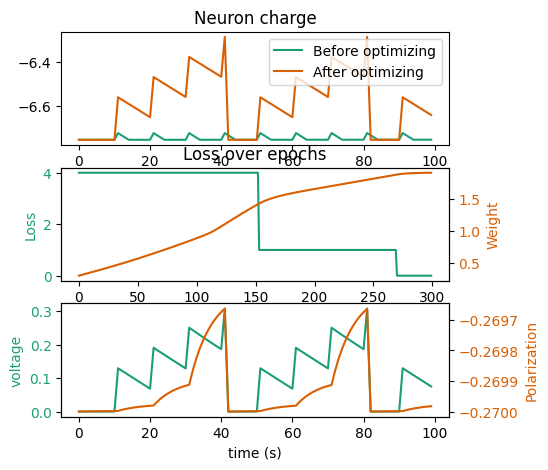

In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# import boilerplot

mpl.rcParams.update(mpl.rcParamsDefault)
# with mpl.style.context("ieeetran"):
plt.figure(figsize=(5, 5))
plt.subplot(3, 1, 1)
plt.title("Neuron charge")
plt.plot(
    V_before * model.layers[2].C_tot_init + P_before * model.layers[2].A,
    # V_before * C_before + P_before * model.layers[2].A,
    c="#1b9e77",
    label="Before optimizing",
)
plt.plot(
    V * model.layers[2].C_tot_init + P * model.layers[2].A,
    # V * C_after + P * model.layers[2].A,
    c="#d95f02",
    label="After optimizing",
)
plt.legend()

ax1 = plt.subplot(3, 1, 2)
plt.title("Loss over epochs")

color = "#1b9e77"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color=color)
ax1.plot(loss_rec, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Weight", color=color)
ax2.plot(param_rec, color=color)
ax2.tick_params(axis="y", labelcolor=color)

ax1 = plt.subplot(3, 1, 3)

color = "#1b9e77"
ax1.set_xlabel("time (s)")
ax1.set_ylabel("voltage", color=color)
ax1.plot(V, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Polarization", color=color)
ax2.plot(P, color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.show()
# plt.savefig("eleanor.svg")